# ĐỒ ÁN 3: ĐÁNH GIÁ TRÊN TẬP DỮ LIỆU MỚI (TWITTER VS FACEBOOK 414)
**Mục tiêu:** 
1. Sử dụng công thức $\eta(G)$ để đánh giá độ bền phổ của đồ thị.
2. So sánh kết quả phân cụm dưới nhiễu LDP giữa 2 nhóm: Twitter (liên kết yếu) và Facebook 414 (liên kết mạnh).

In [1]:
# ==========================================
# CÀI ĐẶT MÔI TRƯỜNG KAGGLE
# ==========================================
import os
if not os.path.exists('/kaggle/working/DataMining-Lab3'):
    !git clone https://github.com/FIT-SE23/DataMining-Lab3.git
%cd /kaggle/working/DataMining-Lab3

import sys
import networkx as nx
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from tqdm import tqdm

sys.path.append('.') 
from src.utils import load_and_preprocess_graph, apply_edge_flipping, get_label_array
from src.model import spectral_clustering
from src.metrics import symmetric_difference_distance, calculate_all_metrics

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

Cloning into 'DataMining-Lab3'...
remote: Enumerating objects: 58, done.
remote: Counting objects: 100% (58/58), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 58 (delta 20), reused 40 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (58/58), 970.00 KiB | 5.95 MiB/s, done.
Resolving deltas: 100% (20/20), done.
/kaggle/working/DataMining-Lab3


## 1. Hàm tính Chỉ số Độ bền Phổ ($\eta(G)$)
Công thức: $\eta(G) = \frac{\Delta(G) \cdot \lambda_2(L_G)}{(\lambda_3(L_G))^2}$
*Trong đó:* $\Delta(G)$ là bậc lớn nhất, $\lambda_2$ và $\lambda_3$ là trị riêng nhỏ thứ 2 và 3. Chỉ số này **càng nhỏ**, đồ thị càng bền vững.

In [2]:
def calculate_spectral_robustness(G):
    # 1. Bậc lớn nhất Delta(G)
    delta = max(dict(G.degree()).values())
    
    # 2. Lấy trị riêng lambda_2 và lambda_3
    L = nx.laplacian_matrix(G).toarray().astype(float)
    eigenvalues = scipy.linalg.eigvalsh(L) # Trả về trị riêng đã sort tăng dần
    
    l2 = eigenvalues[1]
    l3 = eigenvalues[2]
    
    # 3. Tính eta(G)
    eta = (delta * l2) / (l3**2)
    return eta, delta, l2, l3

## 2. Load Dữ liệu và Kiểm tra Độ bền Phổ
Chúng ta sẽ so sánh `twitter_small.edges` và `414.edges`.

In [3]:
# Load và tiền xử lý (Dùng hàm chuẩn trong src/utils.py đã có bước Pruning)
print("Đang tiền xử lý dữ liệu...")
G_twi = load_and_preprocess_graph('./data/twitter_small.edges')
G_fb414 = load_and_preprocess_graph('./data/414.edges')

graphs = {"Twitter (Small)": G_twi, "Facebook 414": G_fb414}

for name, G in graphs.items():
    eta, d, l2, l3 = calculate_spectral_robustness(G)
    print(f"\n--- {name} ---")
    print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
    print(f"Max Degree (Δ): {d}")
    print(f"λ2: {l2:.4f}, λ3: {l3:.4f}")
    print(f"Chỉ số Độ bền Phổ η(G): {eta:.4f}")
    if eta < 1.0: print("=> Đồ thị có tính bền vững phổ TỐT.")
    else: print("=> Đồ thị có tính bền vững phổ YẾU.")

Đang tiền xử lý dữ liệu...

--- Twitter (Small) ---
Nodes: 93, Edges: 1017
Max Degree (Δ): 48
λ2: 5.9066, λ3: 8.5195
Chỉ số Độ bền Phổ η(G): 3.9061
=> Đồ thị có tính bền vững phổ YẾU.

--- Facebook 414 ---
Nodes: 89, Edges: 1248
Max Degree (Δ): 51
λ2: 1.3294, λ3: 10.0754
Chỉ số Độ bền Phổ η(G): 0.6679
=> Đồ thị có tính bền vững phổ TỐT.


## 3. Chạy thực nghiệm (Worst-case d_size & ML Metrics)

In [4]:
probabilities = [i * 0.005 for i in range(1, 40)] # p từ 0.005 đến 0.2
num_trials = 100

# Khởi tạo kết quả
results = {k: {'d_size': [], 'acc': [], 'nmi': []} for k in graphs.keys()}

# Lấy Baseline cho từng đồ thị
baselines = {}
for name, G in graphs.items():
    c1, c2, _ = spectral_clustering(G)
    all_n = list(G.nodes())
    y_t = get_label_array(all_n, c1, c2)
    baselines[name] = {'c1': c1, 'c2': c2, 'y_true': y_t, 'nodes': all_n}

print("\nBắt đầu chạy thực nghiệm nhiễu...")
for p in tqdm(probabilities):
    for name, G in graphs.items():
        tmp_err, tmp_acc, tmp_nmi = [], [], []
        
        for trial in range(num_trials):
            G_noisy = apply_edge_flipping(G, p=p, seed=GLOBAL_SEED + trial)
            c1_n, c2_n, _ = spectral_clustering(G_noisy)
            
            # Tính metrics
            y_p = get_label_array(baselines[name]['nodes'], c1_n, c2_n)
            m = calculate_all_metrics(baselines[name]['y_true'], y_p)
            
            tmp_err.append(symmetric_difference_distance(baselines[name]['c1'], baselines[name]['c2'], c1_n, c2_n))
            tmp_acc.append(m['ACC'])
            tmp_nmi.append(m['NMI'])
            
        results[name]['d_size'].append(np.max(tmp_err))
        results[name]['acc'].append(np.mean(tmp_acc))
        results[name]['nmi'].append(np.mean(tmp_nmi))


Bắt đầu chạy thực nghiệm nhiễu...


100%|██████████| 39/39 [04:44<00:00,  7.29s/it]


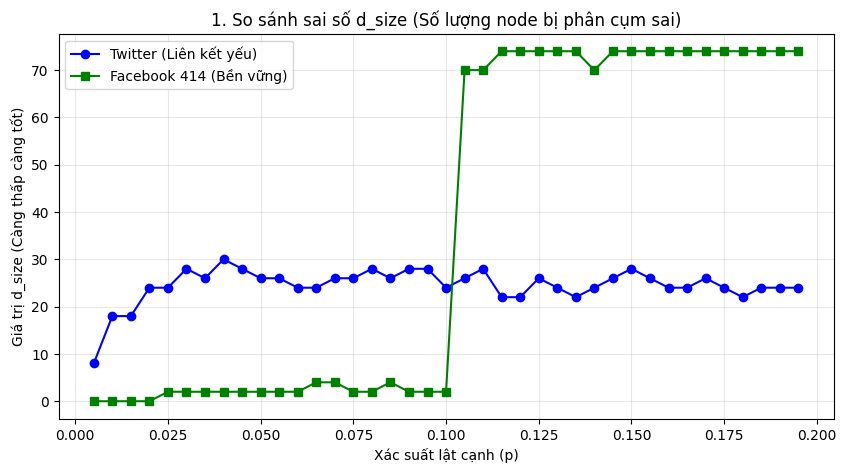

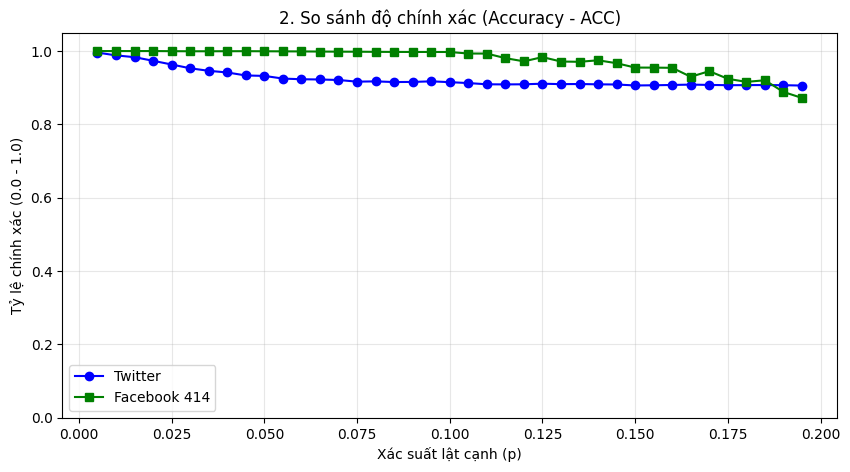

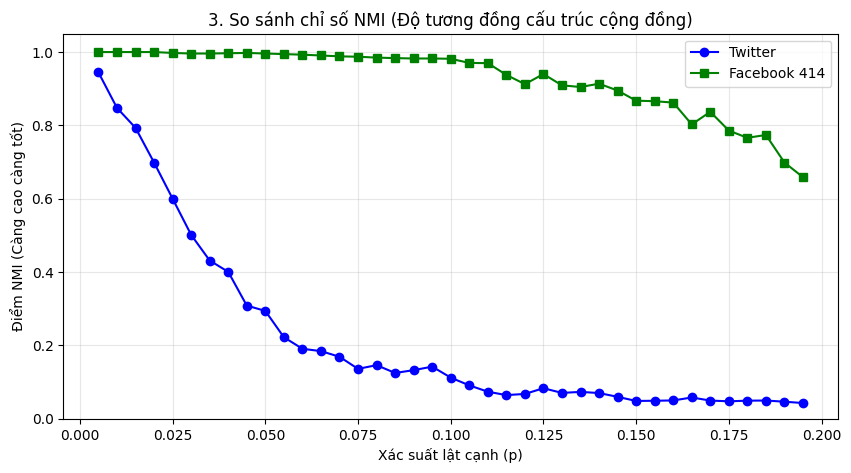

In [5]:
# =============================================================
# BIỂU ĐỒ 1: SAI SỐ KHOẢNG CÁCH (d_size)
# Ý nghĩa: Đếm trực tiếp số lượng node bị xếp sai cụm. Càng thấp càng tốt.
# =============================================================
plt.figure(figsize=(10, 5))
plt.plot(probabilities, results['Twitter (Small)']['d_size'], 'o-', label='Twitter (Liên kết yếu)', color='blue')
plt.plot(probabilities, results['Facebook 414']['d_size'], 's-', label='Facebook 414 (Bền vững)', color='green')

plt.title('1. So sánh sai số d_size (Số lượng node bị phân cụm sai)')
plt.xlabel('Xác suất lật cạnh (p)')
plt.ylabel('Giá trị d_size (Càng thấp càng tốt)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =============================================================
# BIỂU ĐỒ 2: ĐỘ CHÍNH XÁC (ACCURACY)
# Ý nghĩa: Tỷ lệ % node giữ đúng cụm so với ban đầu. 1.0 là hoàn hảo.
# =============================================================
plt.figure(figsize=(10, 5))
plt.plot(probabilities, results['Twitter (Small)']['acc'], 'o-', label='Twitter', color='blue')
plt.plot(probabilities, results['Facebook 414']['acc'], 's-', label='Facebook 414', color='green')

plt.title('2. So sánh độ chính xác (Accuracy - ACC)')
plt.xlabel('Xác suất lật cạnh (p)')
plt.ylabel('Tỷ lệ chính xác (0.0 - 1.0)')
plt.ylim(0, 1.05) # Giới hạn trục Y để dễ quan sát
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =============================================================
# BIỂU ĐỒ 3: ĐỘ TƯƠNG ĐỒNG CẤU TRÚC (NMI)
# Ý nghĩa: Đo mức độ giữ được "hình dạng" cộng đồng. 1.0 là giữ nguyên cấu trúc.
# =============================================================
plt.figure(figsize=(10, 5))
plt.plot(probabilities, results['Twitter (Small)']['nmi'], 'o-', label='Twitter', color='blue')
plt.plot(probabilities, results['Facebook 414']['nmi'], 's-', label='Facebook 414', color='green')

plt.title('3. So sánh chỉ số NMI (Độ tương đồng cấu trúc cộng đồng)')
plt.xlabel('Xác suất lật cạnh (p)')
plt.ylabel('Điểm NMI (Càng cao càng tốt)')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

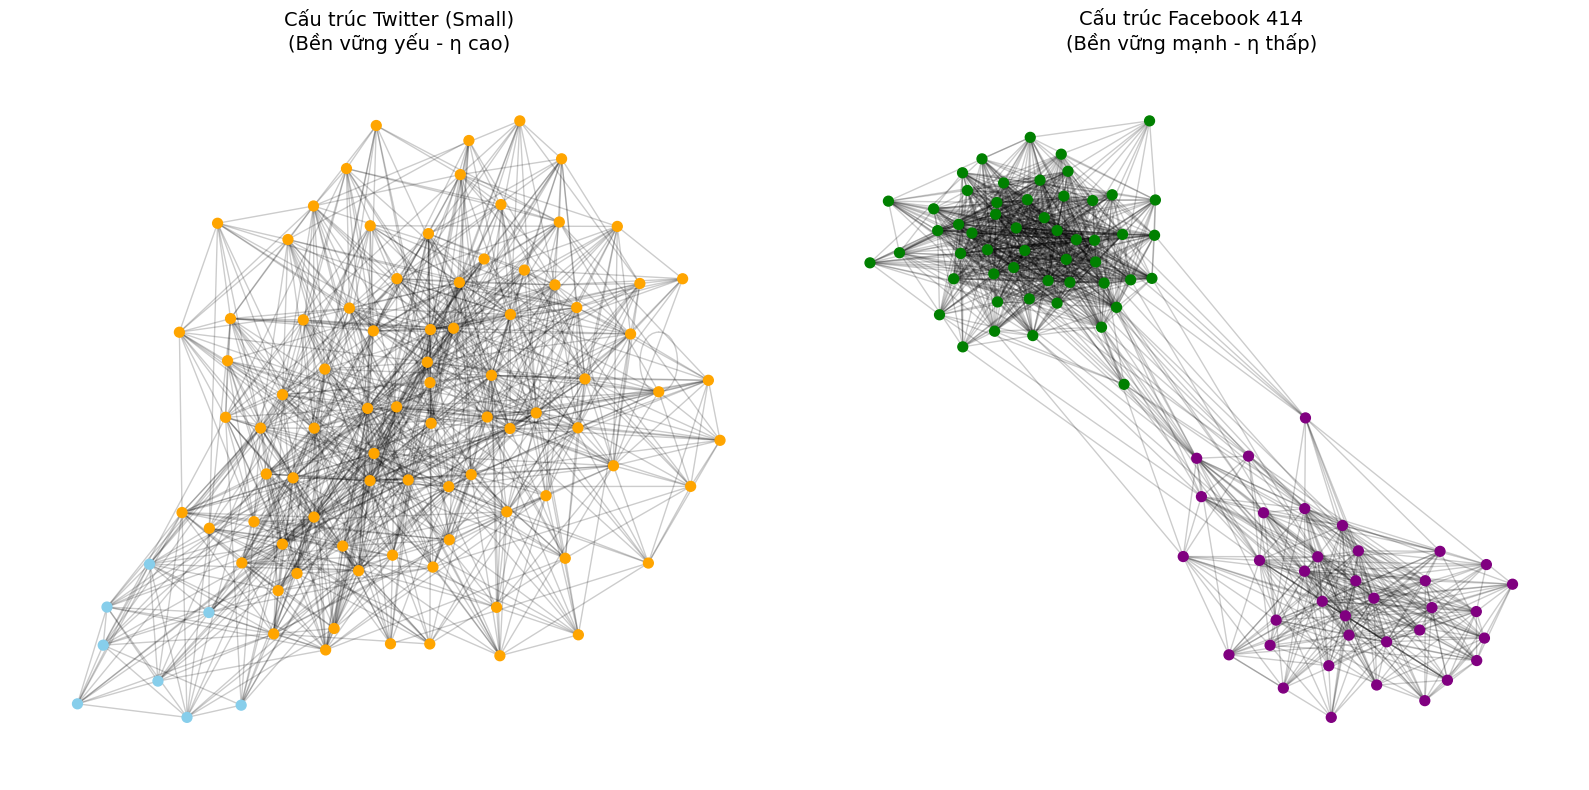

In [6]:
# ==========================================
# TRỰC QUAN HÓA CẤU TRÚC ĐỒ THỊ
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 1. Vẽ đồ thị Twitter (Small)
pos_twi = nx.spring_layout(G_twi, seed=42)
# Lấy nhãn cụm để tô màu
c1_twi = baselines['Twitter (Small)']['c1']
colors_twi = ['orange' if node in c1_twi else 'skyblue' for node in G_twi.nodes()]

nx.draw_networkx_edges(G_twi, pos_twi, ax=ax1, alpha=0.2)
nx.draw_networkx_nodes(G_twi, pos_twi, ax=ax1, node_size=50, node_color=colors_twi)
ax1.set_title(f"Cấu trúc Twitter (Small)\n(Bền vững yếu - η cao)", fontsize=14)
ax1.axis('off')

# 2. Vẽ đồ thị Facebook 414
pos_fb = nx.spring_layout(G_fb414, seed=42)
c1_fb = baselines['Facebook 414']['c1']
colors_fb = ['green' if node in c1_fb else 'purple' for node in G_fb414.nodes()]

nx.draw_networkx_edges(G_fb414, pos_fb, ax=ax2, alpha=0.2)
nx.draw_networkx_nodes(G_fb414, pos_fb, ax=ax2, node_size=50, node_color=colors_fb)
ax2.set_title(f"Cấu trúc Facebook 414\n(Bền vững mạnh - η thấp)", fontsize=14)
ax2.axis('off')

plt.tight_layout()
plt.show()